In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        continue
        # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Importing Libraries

In [3]:
# Importing libraries 

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
 
import cv2
from PIL import Image
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, TensorBoard
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
 
import warnings
warnings.filterwarnings('ignore')
print("Warning suppression active.")

2026-05-05 16:00:18.504883: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777996818.688343      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777996818.747725      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777996819.180287      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777996819.180327      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777996819.180330      57 computation_placer.cc:177] computation placer alr

Warning suppression active.


# Model constants / configs

In [6]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# checkpoint ko path haru

BASE_DIR   = Path("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")
TRAIN_DIR  = BASE_DIR / "Training"
TEST_DIR   = BASE_DIR / "Testing"
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Configsa

IMG_SIZE    = 224          # Input image size (224x224)
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-3
VAL_SPLIT   = 0.2         # 20% of training data → validation

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)

print("="*60)
print("  BRAIN TUMOR MRI - CNN From Scratch")
print("="*60)
print(f"  Image Size  : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size  : {BATCH_SIZE}")
print(f"  Epochs      : {EPOCHS}")
print(f"  Classes     : {CLASS_NAMES}")
print("="*60)


  BRAIN TUMOR MRI - CNN From Scratch
  Image Size  : 224x224
  Batch Size  : 32
  Epochs      : 50
  Classes     : ['glioma', 'meningioma', 'notumor', 'pituitary']


# EDA 


In [7]:
print("\n[EDA] Analyzing dataset structure...")

def count_images(directory: Path) -> dict:
    """Count images per class in a directory."""
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = directory / cls
        if cls_path.exists():
            counts[cls] = len(list(cls_path.glob("*.jpg")) +
                              list(cls_path.glob("*.jpeg")) +
                              list(cls_path.glob("*.png")))
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)
total_train  = sum(train_counts.values())
total_test   = sum(test_counts.values())

print(f"\n  Training samples : {total_train}")
print(f"  Testing  samples : {total_test}")
print(f"  Total            : {total_train + total_test}")
print("\n  Per-class breakdown:")
print(f"  {'Class':<15} {'Train':>8} {'Test':>8} {'Total':>8}")
print("  " + "-"*42)
for cls in CLASS_NAMES:
    print(f"  {cls:<15} {train_counts[cls]:>8} {test_counts[cls]:>8} "
          f"{train_counts[cls]+test_counts[cls]:>8}")


[EDA] Analyzing dataset structure...

  Training samples : 5600
  Testing  samples : 1600
  Total            : 7200

  Per-class breakdown:
  Class              Train     Test    Total
  ------------------------------------------
  glioma              1400      400     1800
  meningioma          1400      400     1800
  notumor             1400      400     1800
  pituitary           1400      400     1800


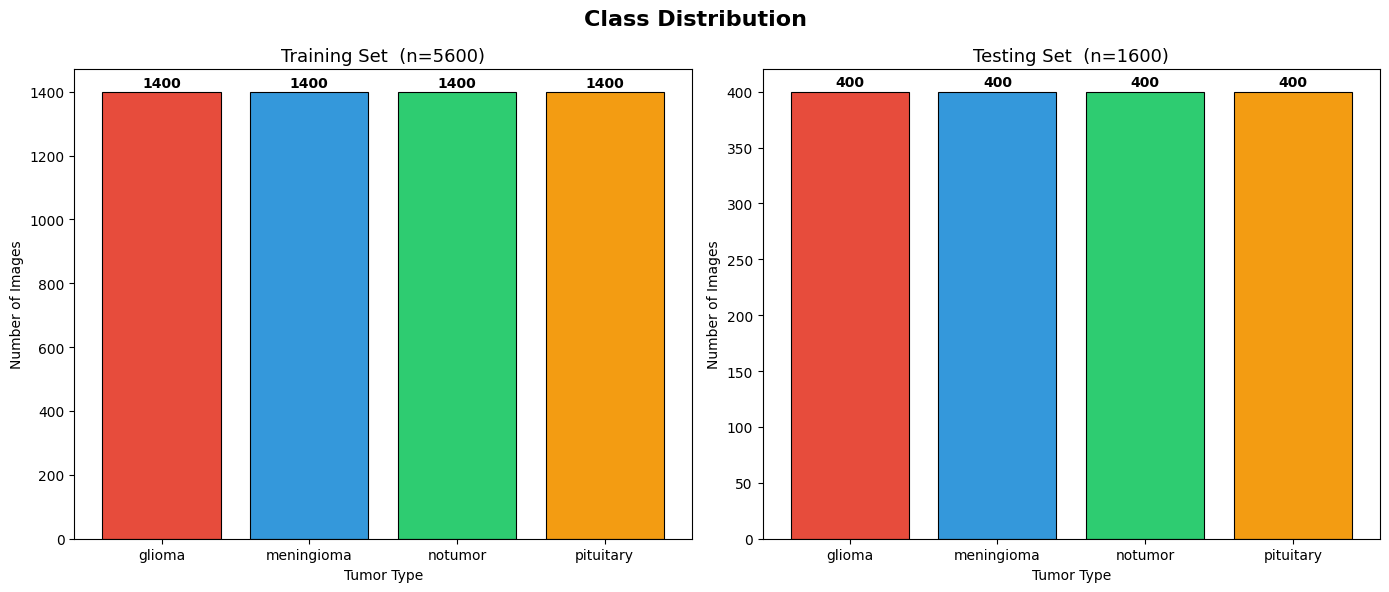

  [✓] Saved: 01_class_distribution.png


In [28]:
# 2.1 Class Distribution Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Class Distribution", fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Training
axes[0].bar(CLASS_NAMES, train_counts.values(), color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title(f"Training Set  (n={total_train})", fontsize=13)
axes[0].set_xlabel("Tumor Type")
axes[0].set_ylabel("Number of Images")
for i, (cls, cnt) in enumerate(train_counts.items()):
    axes[0].text(i, cnt + 15, str(cnt), ha='center', fontweight='bold')

# Testing
axes[1].bar(CLASS_NAMES, test_counts.values(), color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title(f"Testing Set  (n={total_test})", fontsize=13)
axes[1].set_xlabel("Tumor Type")
axes[1].set_ylabel("Number of Images")
for i, (cls, cnt) in enumerate(test_counts.items()):
    axes[1].text(i, cnt + 5, str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 01_class_distribution.png")

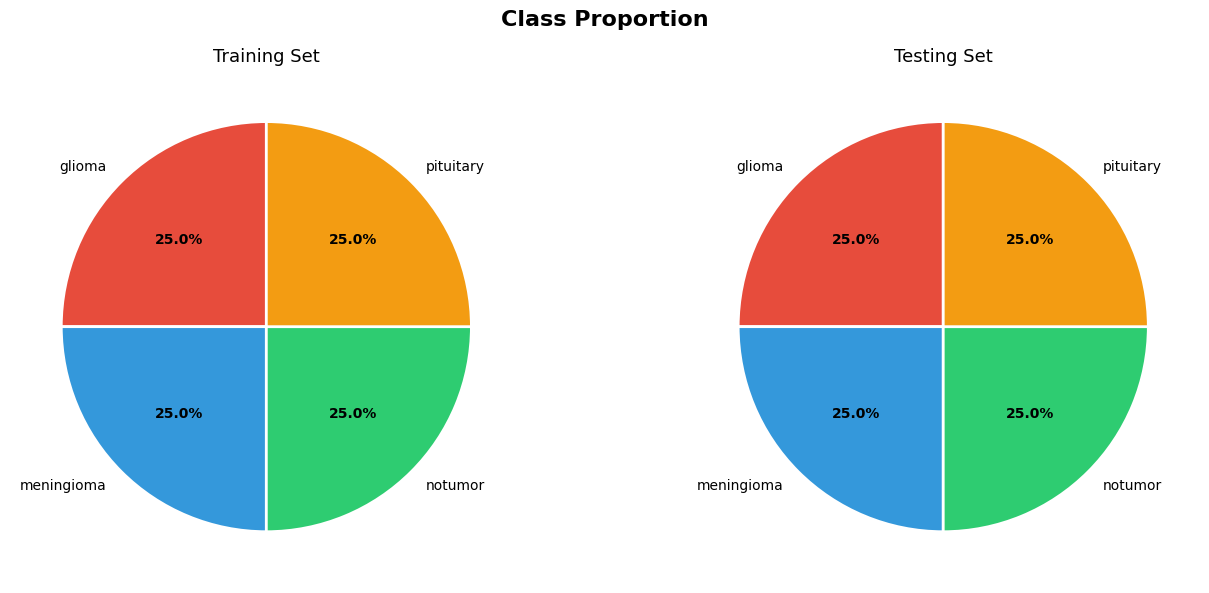

  [✓] Saved: 02_class_proportion.png


In [29]:
# 2.2 Class Imbalance (Pie Chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Class Proportion", fontsize=16, fontweight='bold')

for ax, counts, title in zip(
        axes,
        [train_counts, test_counts],
        ["Training Set", "Testing Set"]
    ):
    wedges, texts, autotexts = ax.pie(
        counts.values(),
        labels=CLASS_NAMES,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for text in autotexts:
        text.set_fontweight('bold')
    ax.set_title(title, fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_class_proportion.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 02_class_proportion.png")

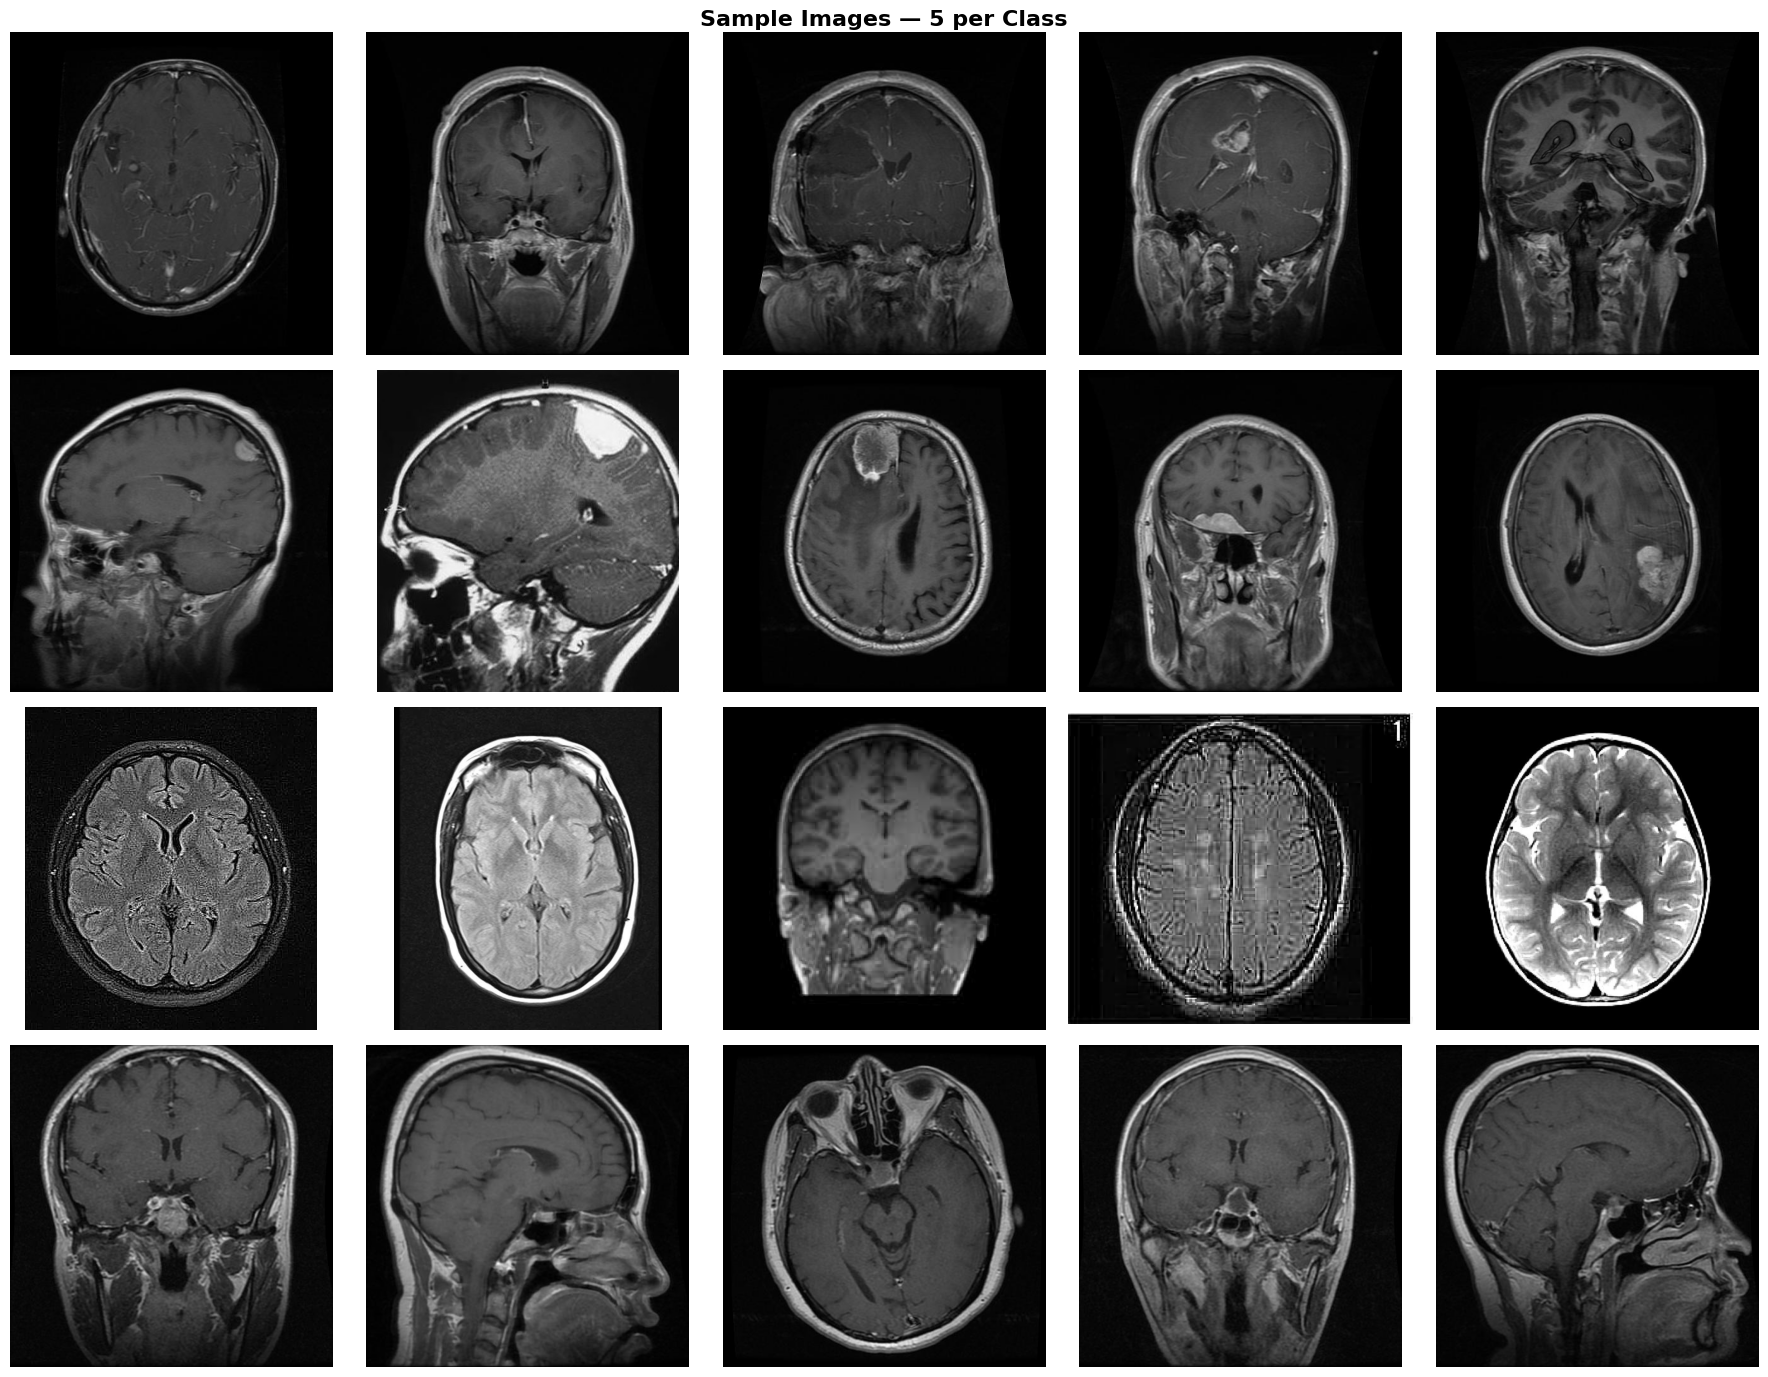

  [✓] Saved: 03_sample_images.png


In [30]:
# 2.3 Sample Images Per Class 
def load_sample_images(directory, cls, n=5):
    """Load n random sample images from a class folder."""
    folder = directory / cls
    paths  = list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png"))
    chosen = random.sample(paths, min(n, len(paths)))
    images = []
    for p in chosen:
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
    return images

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(18, 14))
fig.suptitle("Sample Images — 5 per Class", fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    samples = load_sample_images(TRAIN_DIR, cls, n=5)
    for col, img in enumerate(samples):
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=13, fontweight='bold',
                                       rotation=90, labelpad=60)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 03_sample_images.png")


  [EDA] Analyzing image dimensions...


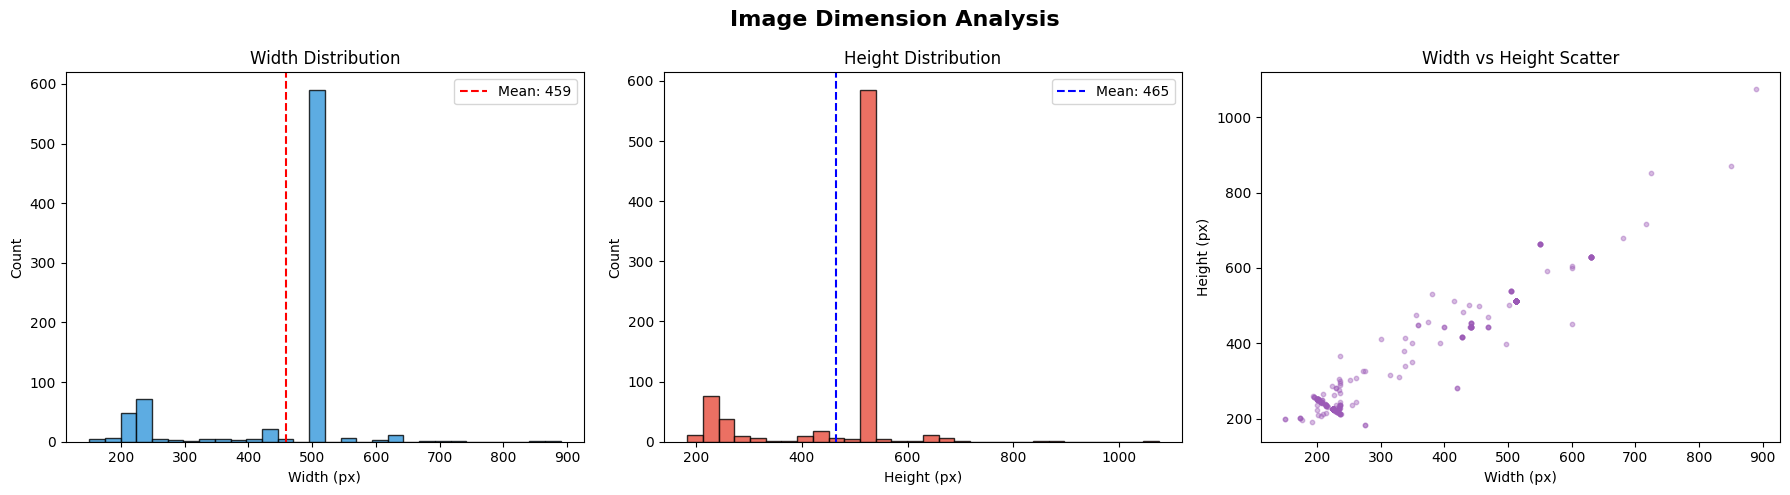

  Avg Width  : 459.3px  |  Std: 116.5px
  Avg Height : 464.7px  |  Std: 112.8px
  [✓] Saved: 04_image_dimensions.png


In [31]:
print("\n  [EDA] Analyzing image dimensions...")

widths, heights = [], []
for cls in CLASS_NAMES:
    cls_path = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    # Sample up to 200 per class for speed
    for p in random.sample(img_paths, min(200, len(img_paths))):
        img = Image.open(p)
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Image Dimension Analysis", fontsize=16, fontweight='bold')

axes[0].hist(widths,  bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
axes[0].legend()

axes[1].hist(heights, bins=30, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")
axes[1].axvline(np.mean(heights), color='blue', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
axes[1].legend()

axes[2].scatter(widths, heights, alpha=0.4, color='#9b59b6', s=10)
axes[2].set_title("Width vs Height Scatter")
axes[2].set_xlabel("Width (px)")
axes[2].set_ylabel("Height (px)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_image_dimensions.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"  Avg Width  : {np.mean(widths):.1f}px  |  Std: {np.std(widths):.1f}px")
print(f"  Avg Height : {np.mean(heights):.1f}px  |  Std: {np.std(heights):.1f}px")
print("  [✓] Saved: 04_image_dimensions.png")


  [EDA] Analyzing pixel intensities...


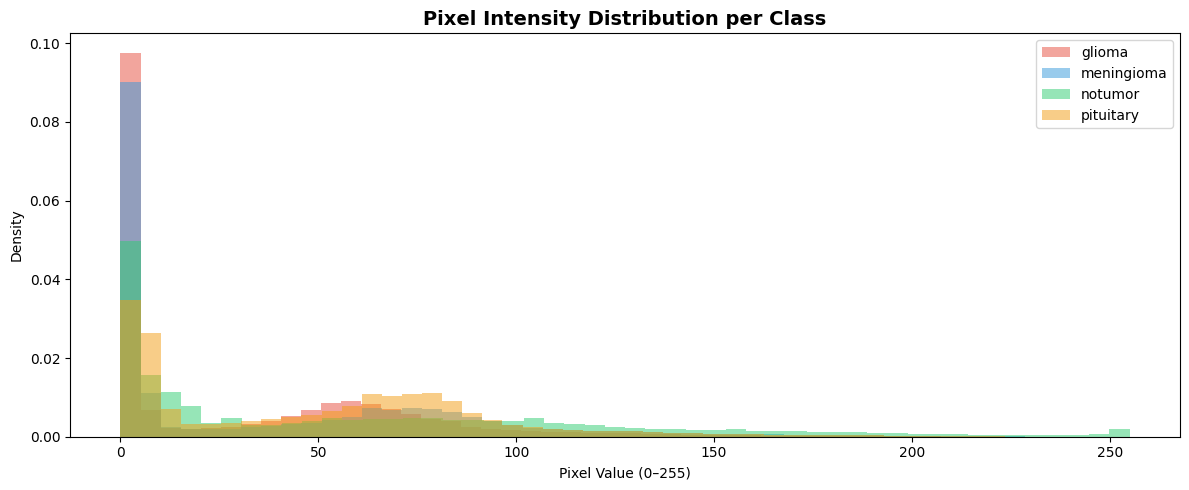

  [✓] Saved: 05_pixel_intensity.png


In [32]:
print("\n  [EDA] Analyzing pixel intensities...")

intensity_data = {cls: [] for cls in CLASS_NAMES}
for cls in CLASS_NAMES:
    cls_path  = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    sample    = random.sample(img_paths, min(50, len(img_paths)))
    for p in sample:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        intensity_data[cls].extend(img.flatten().tolist())

fig, ax = plt.subplots(figsize=(12, 5))
for cls, color in zip(CLASS_NAMES, colors):
    vals = np.array(intensity_data[cls])
    ax.hist(vals, bins=50, alpha=0.5, color=color, label=cls, density=True)
ax.set_title("Pixel Intensity Distribution per Class", fontsize=14, fontweight='bold')
ax.set_xlabel("Pixel Value (0–255)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_pixel_intensity.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 05_pixel_intensity.png")

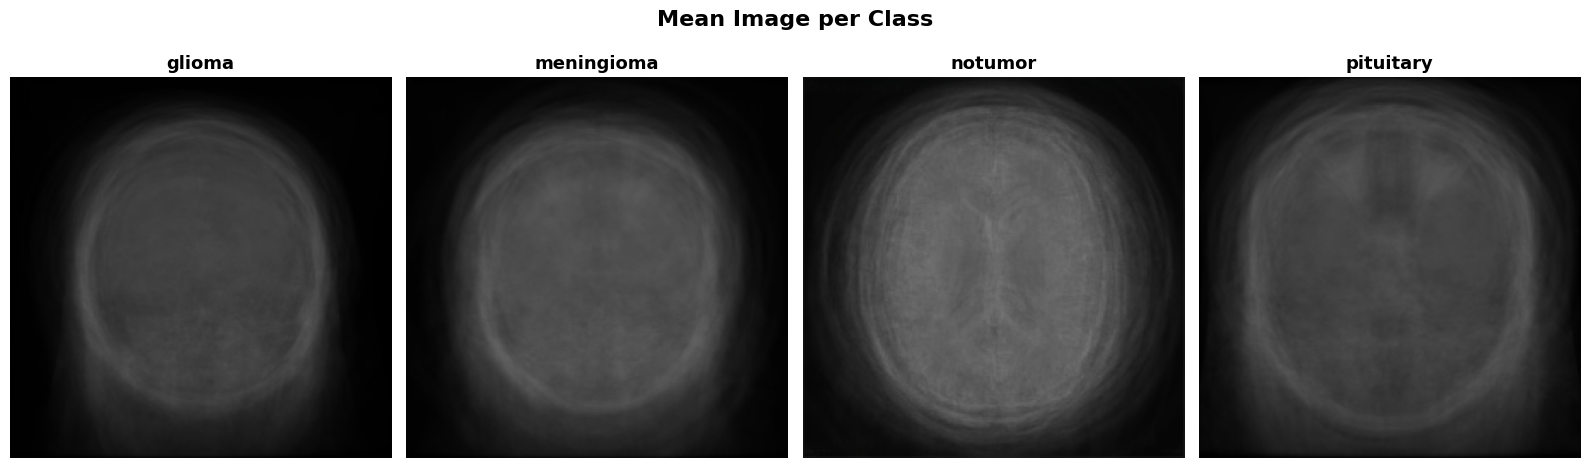

  [✓] Saved: 06_mean_images.png

[✓] EDA Complete!



In [33]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 5))
fig.suptitle("Mean Image per Class", fontsize=16, fontweight='bold')

for ax, cls in zip(axes, CLASS_NAMES):
    cls_path  = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    sample    = random.sample(img_paths, min(100, len(img_paths)))
    stack     = []
    for p in sample:
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        stack.append(img.astype(np.float32))
    mean_img = np.mean(stack, axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(cls, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_mean_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 06_mean_images.png")

print("\n[✓] EDA Complete!\n")

# Loading Datasets (train/val/test)

In [8]:
import glob
import numpy as np
from sklearn.model_selection import train_test_split

#  3.1 Build file-level train/val split 
all_files, all_labels = [], []
for i, cls in enumerate(CLASS_NAMES):
    files = sorted(glob.glob(os.path.join(TRAIN_DIR, cls, "*")))
    all_files.extend(files)
    all_labels.extend([i] * len(files))

train_files, val_files, train_labels, val_labels = train_test_split(
    all_files, all_labels,
    test_size    = VAL_SPLIT,
    stratify     = all_labels,
    random_state = SEED
)

print(f"  Train: {len(train_files)} | Val: {len(val_files)}")

# 3.2 Image loader 
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

def paths_to_dataset(file_paths, labels, batch_size, shuffle=False):
    labels_oh = tf.keras.utils.to_categorical(labels, NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels_oh))
    if shuffle:
        ds = ds.shuffle(len(file_paths), seed=SEED, reshuffle_each_iteration=True)
    ds = (ds
          .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))
    return ds

# 3.3 Build datasets 
train_ds_full = paths_to_dataset(train_files, train_labels, BATCH_SIZE, shuffle=True)
val_ds        = paths_to_dataset(val_files,   val_labels,   BATCH_SIZE, shuffle=False)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels      = 'inferred',
    label_mode  = 'categorical',
    class_names = CLASS_NAMES,
    image_size  = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    shuffle     = False
)

  Train: 4480 | Val: 1120


I0000 00:00:1777996895.376874      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777996895.382667      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1600 files belonging to 4 classes.


# Normalization layers and Data Augumentations

In [35]:
import os
print(os.listdir(TRAIN_DIR))  # what does this show?
# and how many images per class?
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"{cls}: {count} images")

['pituitary', 'notumor', 'meningioma', 'glioma']
glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images


In [36]:
import os
sample_files = os.listdir(os.path.join(TRAIN_DIR, 'glioma'))[:10]
for f in sample_files:
    print(f)
    

Tr-gl_1362.jpg
Tr-gl_821.jpg
Tr-gl_825.jpg
Tr-gl_315.jpg
Tr-gl_52.jpg
Tr-gl_626.jpg
Tr-gl_827.jpg
Tr-gl_1033.jpg
Tr-gl_1096.jpg
Tr-gl_1290.jpg


In [9]:
# Preprocessing 
normalization_layer = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(images, labels):
    images = normalization_layer(images)
    images = data_augmentation(images, training=True)
    return images, labels

def preprocess_eval(images, labels):
    images = normalization_layer(images)
    return images, labels

# Build final datasets 
train_ds = (train_ds_full
            .cache()
            .map(preprocess_train, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

val_ds = (val_ds
          .cache()
          .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
          .prefetch(AUTOTUNE))

test_ds = (test_ds
           .cache()
           .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
           .prefetch(AUTOTUNE))

In [10]:
sample_batch_raw, sample_labels = next(iter(
    tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        labels='inferred',
        label_mode='categorical',
        class_names=CLASS_NAMES,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=4,
        shuffle=True,
        seed=SEED
    )
))


Found 5600 files belonging to 4 classes.


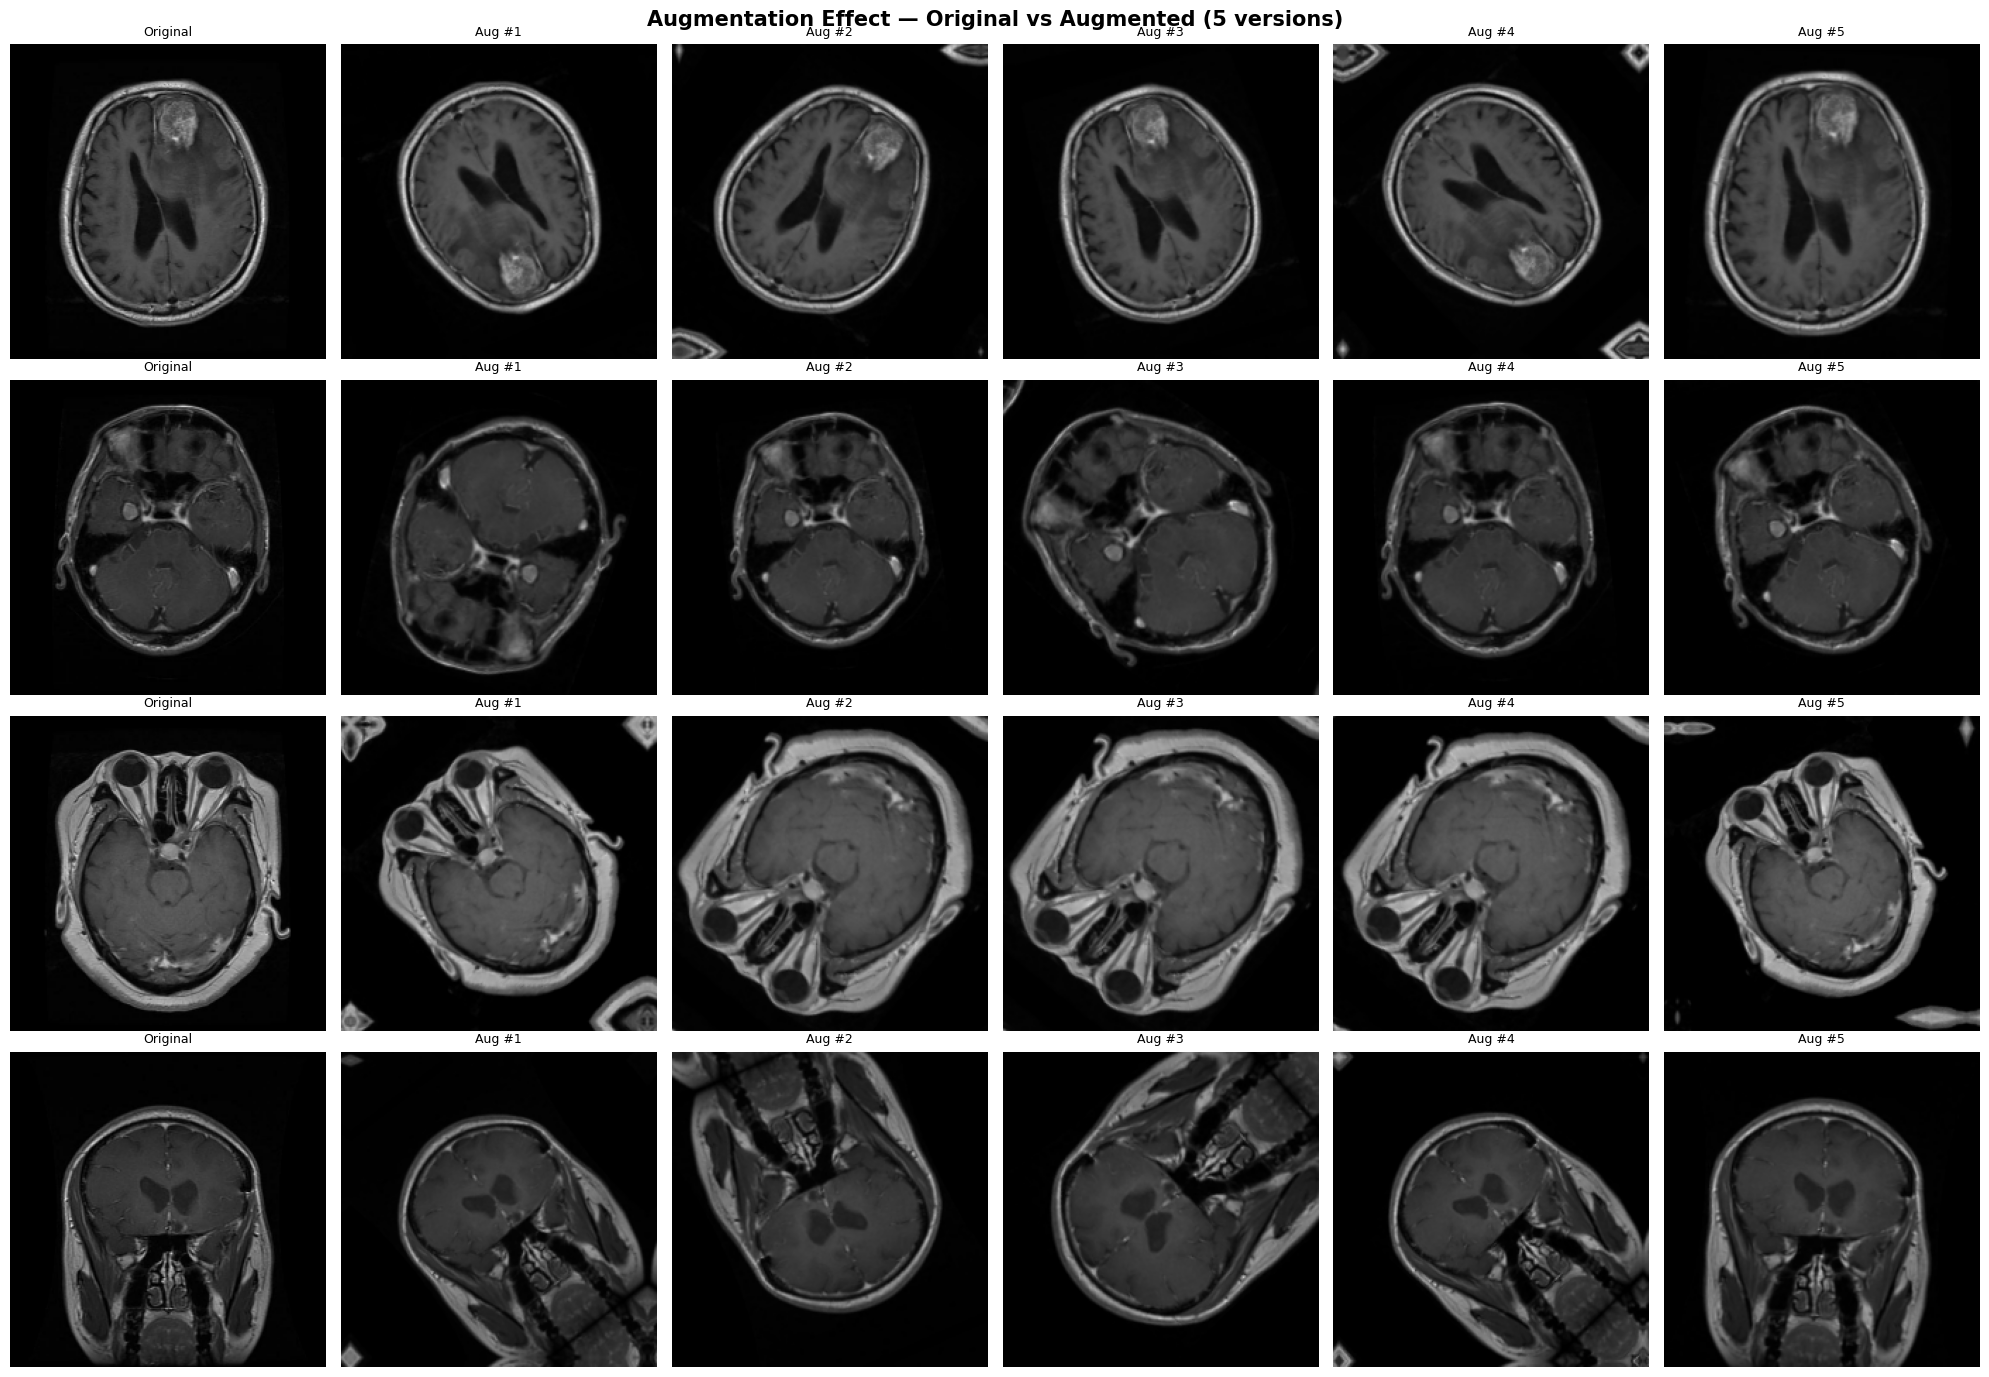

  [✓] Saved: 07_augmentation_preview.png


In [39]:
fig, axes = plt.subplots(4, 6, figsize=(20, 14))
fig.suptitle("Augmentation Effect — Original vs Augmented (5 versions)",
             fontsize=15, fontweight='bold')

aug_pipeline = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

for row in range(4):
    img      = sample_batch_raw[row]
    label_id = tf.argmax(sample_labels[row]).numpy()
    cls_name = CLASS_NAMES[label_id]

    # Original
    axes[row, 0].imshow(img.numpy().astype(np.uint8))
    axes[row, 0].set_title("Original", fontsize=9)
    axes[row, 0].set_ylabel(cls_name, fontsize=11, fontweight='bold')
    axes[row, 0].axis('off')

    # 5 augmented versions
    for col in range(1, 6):
        aug_img = aug_pipeline(tf.expand_dims(img, 0), training=True)[0]
        axes[row, col].imshow(aug_img.numpy().astype(np.uint8))
        axes[row, col].set_title(f"Aug #{col}", fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_augmentation_preview.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 07_augmentation_preview.png")

 # Baseline CNN Model 

In [40]:
from tensorflow.keras.models import Sequential
baseline_model = Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
 
    # Conv Block 1 — 32 filters, 3×3, ReLU → low-level edges
    layers.Conv2D(32, (3,3), padding='same', activation='relu', kernel_initializer='he_normal'),
    layers.MaxPooling2D((2,2)),      # 224 → 112
    # Conv Block 2 — 64 filters, 3×3, ReLU → mid-level textures
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer='he_normal'),
    layers.MaxPooling2D((2,2)),      # 112 → 56
 
    # Conv Block 3 — 128 filters, 3×3, ReLU → high-level shapes
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer='he_normal'),
    layers.MaxPooling2D((2,2)),      # 56 → 28
    layers.Flatten(),               # (28,28,128) → 100,352
 
    # FCN 1 — 512 units
    layers.Dense(512, activation='relu', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),

    # FCN 2 — 256 units
    layers.Dense(256, activation='relu', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),

    # FCN 3 — 128 units
    layers.Dense(128, activation='relu', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),

    # Output — 4 classes, softmax
    layers.Dense(NUM_CLASSES, activation='softmax')
 
], name="Baseline_CNN")
baseline_model.summary()
baseline_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
)

total_samples = total_train
class_weights = {}
for i, cls in enumerate(CLASS_NAMES):
    count = train_counts[cls]
    class_weights[i] = total_samples / (NUM_CLASSES * count)

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,638,724 (196.99 MB)

 Trainable params: 51,638,724 (196.99 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Training with time tracking 
import time

train_start = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    class_weight    = class_weights,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint(str(OUTPUT_DIR / "baseline_best.keras"), monitor='val_accuracy', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
    ],
    verbose = 1
)

train_end = time.time()
baseline_training_time = train_end - train_start

hours, rem       = divmod(baseline_training_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"\nBaseline CNN Training Time: {int(hours):02d}h {int(minutes):02d}m {seconds:.2f}s")
print(f"Total epochs run: {len(history_baseline.history['loss'])}")

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 269ms/step - accuracy: 0.4064 - auc: 0.6728 - loss: 5.0525 - precision: 0.4473 - recall: 0.1947 - val_accuracy: 0.7241 - val_auc: 0.9165 - val_loss: 0.9153 - val_precision: 0.7568 - val_recall: 0.6500 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 209ms/step - accuracy: 0.6854 - auc: 0.8978 - loss: 0.9736 - precision: 0.7379 - recall: 0.5937 - val_accuracy: 0.7768 - val_auc: 0.9428 - val_loss: 0.7600 - val_precision: 0.8095 - val_recall: 0.7321 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 27s 185ms/step - accuracy: 0.7128 - auc: 0.9150 - loss: 0.8853 - precision: 0.7602 - recall: 0.6463 - val_accuracy: 0.7027 - val_auc: 0.9153 - val_loss: 0.9056 - val_precision: 0.7201 - val_recall: 0.6661 - learning_rate: 0.0010
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 27s 185ms/step - accuracy: 0.7477 - auc: 0.9313 - loss: 0.7983 - precision: 0.7836 - recall: 0.6930 - val_accuracy: 0.7670 - val_auc: 0.9363 - val_loss: 

# Evaluating Baseline model

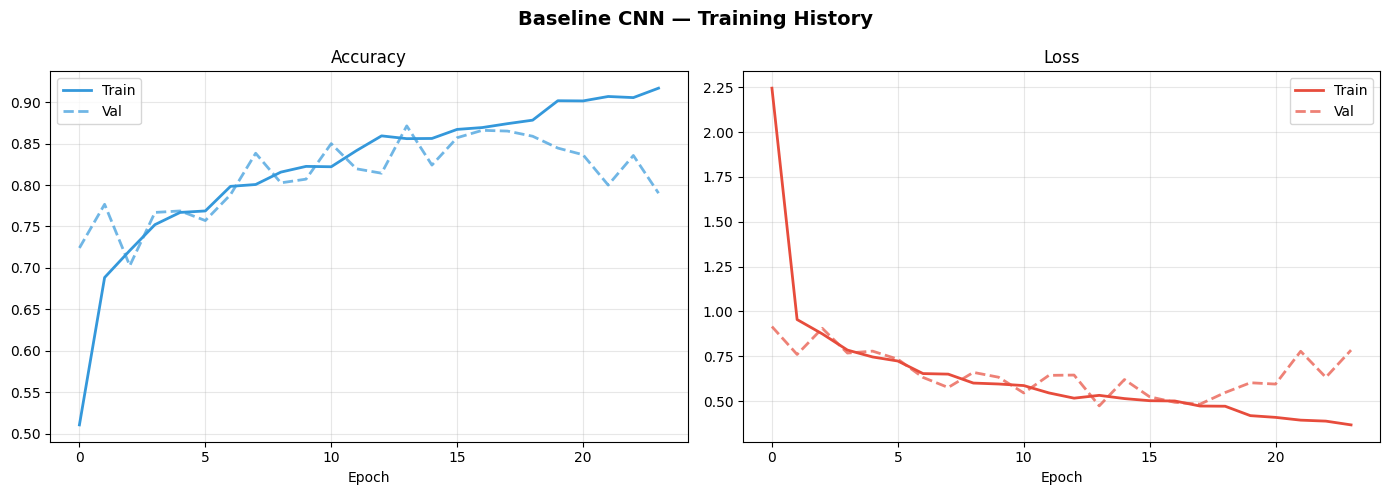

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline CNN — Training History", fontsize=14, fontweight='bold')
 
for ax, (m, title, c) in zip(axes, [('accuracy','Accuracy','#3498db'), ('loss','Loss','#e74c3c')]):
    ax.plot(history_baseline.history[m],          label='Train', color=c, linewidth=2)
    ax.plot(history_baseline.history[f'val_{m}'], label='Val',   color=c, linewidth=2, linestyle='--', alpha=0.7)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_baseline_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [43]:
test_results_b = baseline_model.evaluate(test_ds, verbose=1)
 
y_pred_b = np.argmax(baseline_model.predict(test_ds, verbose=0), axis=1)
y_true_b = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])
 
print(classification_report(y_true_b, y_pred_b, target_names=CLASS_NAMES))

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.6654 - auc: 0.8607 - loss: 1.5277 - precision: 0.6759 - recall: 0.6540
              precision    recall  f1-score   support

      glioma       0.84      0.60      0.70       400
  meningioma       0.78      0.61      0.68       400
     notumor       0.74      1.00      0.85       400
   pituitary       0.84      0.97      0.90       400

    accuracy                           0.80      1600
   macro avg       0.80      0.80      0.78      1600
weighted avg       0.80      0.80      0.78      1600



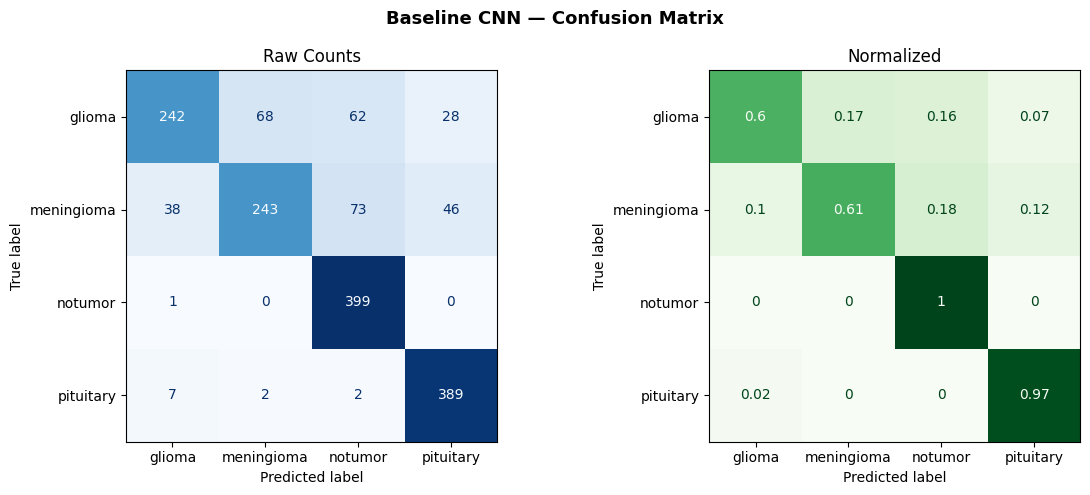

In [44]:
cm_b = confusion_matrix(y_true_b, y_pred_b)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Baseline CNN — Confusion Matrix", fontsize=13, fontweight='bold')
ConfusionMatrixDisplay(cm_b, display_labels=CLASS_NAMES).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Raw Counts")
cm_norm = cm_b.astype('float') / cm_b.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title("Normalized")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "16_baseline_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step


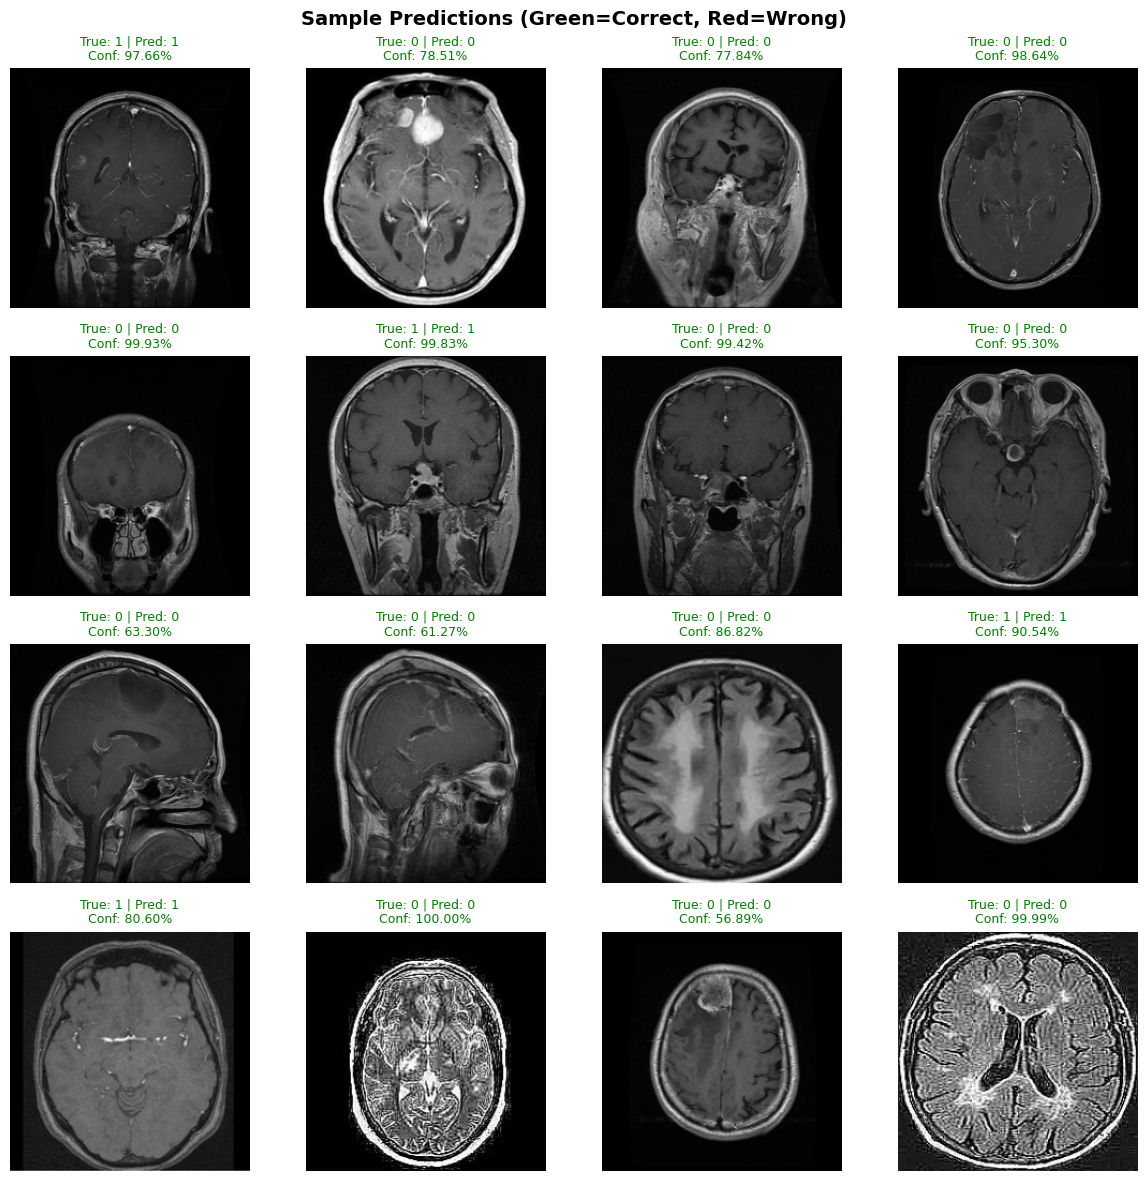

Saved to OUTPUT_DIR/sample_predictions.png


In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of validation images
sample_images, sample_labels = next(iter(val_ds))

# Get predictions
predictions = baseline_model.predict(sample_images)

# If binary classification
predicted_classes = (predictions > 0.5).astype(int).flatten()

# If multi-class classification
# predicted_classes = np.argmax(predictions, axis=1)
# true_classes = np.argmax(sample_labels.numpy(), axis=1)  # if one-hot encoded

true_classes = sample_labels.numpy().astype(int).flatten()

# Plot sample images with predictions
n_samples = 16  # number of images to display
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i in range(n_samples):
    img = sample_images[i].numpy()
    
    # Denormalize if needed (if images were normalized to [0,1] skip this)
    img = np.clip(img, 0, 1)
    
    axes[i].imshow(img)
    
    pred_label  = predicted_classes[i]
    true_label  = true_classes[i]
    confidence  = predictions[i][0] if predictions.shape[-1] == 1 else np.max(predictions[i])
    
    # Color code: green = correct, red = wrong
    color = 'green' if pred_label == true_label else 'red'
    
    axes[i].set_title(
        f"True: {true_label} | Pred: {pred_label}\nConf: {confidence:.2%}",
        color=color, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to OUTPUT_DIR/sample_predictions.png")

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

In [48]:
gap = history_baseline.history['accuracy'][-1] - max(history_baseline.history['val_accuracy'])
print(f"\nTrain/Val gap: {gap:.4f}")
print(f"Test Accuracy : {test_results_b[1]:.4f}  |  AUC: {test_results_b[2]:.4f}  |  F1: {f1_score(y_true_b, y_pred_b, average='macro'):.4f}")


Train/Val gap: 0.0455
Test Accuracy : 0.7956  |  AUC: 0.9378  |  F1: 0.7848


the gap being too big suggests that the model is overfitting 

In [49]:
baseline_model.save(str(OUTPUT_DIR / "baseline_cnn_final.keras"))
print(f"Model saved → {OUTPUT_DIR / 'baseline_cnn_final.keras'}")

Model saved → /kaggle/working/outputs/baseline_cnn_final.keras


# Deeper CNN model with SGD optimizer

In [11]:
def conv_block(x, filters, block_name, dropout_rate=0.25):
    # First conv
    x = layers.Conv2D(
        filters, (3, 3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name=f"{block_name}_conv1",
        use_bias=False
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.Activation('relu', name=f"{block_name}_relu1")(x)
    # Second conv
    x = layers.Conv2D(
        filters, (3, 3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name=f"{block_name}_conv2",
        use_bias=False
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)
    x = layers.Activation('relu', name=f"{block_name}_relu2")(x)
    # Downsample
    x = layers.MaxPooling2D((2, 2), name=f"{block_name}_pool")(x)
    x = layers.SpatialDropout2D(dropout_rate, name=f"{block_name}_sdrop")(x)
    return x


def build_cnn_v3(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape, name="input")

    x = conv_block(inputs, filters=32,  block_name="block1", dropout_rate=0.10)
    # Output: (112, 112, 32)
    x = conv_block(x,      filters=64,  block_name="block2", dropout_rate=0.15)
    # Output: (56, 56, 64)
    x = conv_block(x,      filters=128, block_name="block3", dropout_rate=0.20)
    # Output: (28, 28, 128)
    x = conv_block(x,      filters=256, block_name="block4", dropout_rate=0.20)
    # Output: (14, 14, 256)
    x = conv_block(x,      filters=512, block_name="block5", dropout_rate=0.25)
    # Output: (7, 7, 512)

    x = layers.GlobalAveragePooling2D(name="gap")(x)

    x = layers.Dense(512, use_bias=False, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4), name="dense1")(x)
    x = layers.BatchNormalization(name="dense1_bn")(x)
    x = layers.Activation('relu', name="dense1_relu")(x)
    x = layers.Dropout(0.40, name="dense1_drop")(x)

    x = layers.Dense(256, use_bias=False, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4), name="dense2")(x)
    x = layers.BatchNormalization(name="dense2_bn")(x)
    x = layers.Activation('relu', name="dense2_relu")(x)
    x = layers.Dropout(0.30, name="dense2_drop")(x)

    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="BrainTumorCNN_v3")
    return model

In [12]:
model = build_cnn_v3()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Penalize glioma and meningioma misses harder
class_weights = {
    0: 1.5,   # glioma      — was 0.59 recall
    1: 1.5,   # meningioma  — was 0.59 recall
    2: 0.7,   # notumor     — was over-predicted
    3: 1.0    # pituitary   — already strong
}

In [13]:
try:
    tf.keras.utils.plot_model(
        model,
        to_file=str(OUTPUT_DIR / "08_model_architecture.png"),
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=80
    )
    print("  [✓] Saved: 08_model_architecture.png")
except Exception:
    print("  [!] Model plot requires pydot/graphviz — skipping")

  [✓] Saved: 08_model_architecture.png


In [53]:
#rm -rf /kaggle/working/outputs

In [15]:
import time

In [ ]:
print("\n[TRAIN] Compiling and training...\n")

# Resume support for multi-day training 
LATEST_CHECKPOINT = CHECKPOINT_DIR / "latest.keras"
BEST_CHECKPOINT   = OUTPUT_DIR / "best_model.keras"
TRAIN_LOG         = OUTPUT_DIR / "training_log.csv"
TIMING_LOG        = OUTPUT_DIR / "training_timing.csv"   # ← NEW
initial_epoch     = 0

if LATEST_CHECKPOINT.exists():
    print(f"  [RESUME] Loading latest checkpoint: {LATEST_CHECKPOINT}")
    model = keras.models.load_model(str(LATEST_CHECKPOINT))
    if TRAIN_LOG.exists():
        try:
            initial_epoch = len(pd.read_csv(TRAIN_LOG))
        except Exception:
            initial_epoch = 0
elif BEST_CHECKPOINT.exists():
    print(f"  [RESUME] Loading best checkpoint: {BEST_CHECKPOINT}")
    model = keras.models.load_model(str(BEST_CHECKPOINT))
    print("  [RESUME] Best checkpoint loaded without epoch state; training will restart from epoch 1")
else:
    model = build_cnn_v3()

# Loss 
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

if not getattr(model, 'optimizer', None):
    model.compile(
        optimizer = keras.optimizers.SGD(         # ← CHANGED from Adam
            learning_rate = 1e-2,                 #   SGD needs higher LR than Adam
            momentum      = 0.9,                  #   momentum for smoother updates
            nesterov      = True                  #   Nesterov gives slightly better convergence
        ),
        loss    = loss_fn,
        metrics = [
            'accuracy',
            keras.metrics.AUC(name='auc', multi_label=False),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )

# LR Warmup (adjusted for SGD) 
# SGD is more sensitive to LR — ramp from 1e-3 → 1e-2 over 5 epochs
def lr_scheduler(epoch, lr):
    if epoch < 5:
        return 1e-2 * ((epoch + 1) / 5)
    return lr

# Epoch Timing Callback 
class EpochTimingLogger(keras.callbacks.Callback):
    """Records per-epoch wall-clock time to a CSV."""
    def __init__(self, log_path):
        super().__init__()
        self.log_path   = log_path
        self.epoch_start = None
        # Write header only if file doesn't exist yet
        if not Path(log_path).exists():
            pd.DataFrame(columns=['epoch', 'epoch_time_sec', 'cumulative_time_sec']
                        ).to_csv(log_path, index=False)
        self.cumulative = 0.0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        duration         = time.time() - self.epoch_start
        self.cumulative += duration
        row = pd.DataFrame([{
            'epoch'               : epoch + 1,
            'epoch_time_sec'      : round(duration, 2),
            'cumulative_time_sec' : round(self.cumulative, 2)
        }])
        row.to_csv(self.log_path, mode='a', header=False, index=False)
        print(f"    ⏱  Epoch {epoch+1} time: {duration:.1f}s  |  Total so far: {self.cumulative/60:.1f}min")

# Callbacks 
callbacks = [
    EpochTimingLogger(str(TIMING_LOG)),              # ← NEW
    keras.callbacks.LearningRateScheduler(lr_scheduler, verbose=1),
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath       = str(BEST_CHECKPOINT),
        monitor        = 'val_loss',
        save_best_only = True,
        verbose        = 1
    ),
    ModelCheckpoint(
        filepath       = str(LATEST_CHECKPOINT),
        save_best_only = False,
        save_freq      = 'epoch',
        verbose        = 0
    ),
    keras.callbacks.CSVLogger(str(TRAIN_LOG), append=True),
    keras.callbacks.BackupAndRestore(backup_dir=str(CHECKPOINT_DIR / 'backup_state')),
    TensorBoard(
        log_dir        = str(OUTPUT_DIR / "logs"),
        histogram_freq = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-6,         # ← raised floor slightly; 1e-7 is too small for SGD
        verbose  = 1
    ),
]

# Train 
print("\n[TRAIN] Starting training...\n")
train_start = time.time()

history = model.fit(
    train_ds,
    initial_epoch   = initial_epoch,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = callbacks,
    verbose         = 1
)

train_end  = time.time()
elapsed    = train_end - train_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)

print(f"\n Training complete!")
print(f"   Total training time : {int(hours):02d}h {int(mins):02d}m {secs:.2f}s")
print(f"   Epoch timing log   : {TIMING_LOG}")


[TRAIN] Compiling and training...


[TRAIN] Starting training...


Epoch 1: LearningRateScheduler setting learning rate to 0.002.
Epoch 1/50


I0000 00:00:1777996999.633966     144 service.cc:152] XLA service 0x7ba218004220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777996999.634015     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777996999.634019     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777997000.767735     144 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-05 16:03:30.505883: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:03:30.660611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:03:33.569831: E external/local_xl

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.4086 - auc: 0.6809 - loss: 1.9669 - precision: 0.4889 - recall: 0.2547    ⏱  Epoch 1 time: 72.9s  |  Total so far: 1.2min

Epoch 1: val_loss improved from inf to 2.57167, saving model to /kaggle/working/outputs/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 287ms/step - accuracy: 0.4089 - auc: 0.6813 - loss: 1.9662 - precision: 0.4894 - recall: 0.2550 - val_accuracy: 0.2554 - val_auc: 0.5970 - val_loss: 2.5717 - val_precision: 0.2631 - val_recall: 0.2518 - learning_rate: 0.0020

Epoch 2: LearningRateScheduler setting learning rate to 0.004.
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.5499 - auc: 0.8026 - loss: 1.7026 - precision: 0.6589 - recall: 0.3919    ⏱  Epoch 2 time: 32.5s  |  Total so far: 1.8min

Epoch 2: val_loss improved from 2.57167 to 2.05926, saving model to /kaggle/working/outputs/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 239ms/step - accuracy: 0.5500 - auc: 0.8027 - loss: 1.7024 -

In this cell, I compile and train my baseline CNN using SGD with momentum and Nesterov acceleration. I also include resume logic, so if a checkpoint exists, training can continue instead of starting from scratch. During training, the metrics show that the model learns steadily: training and validation performance improve across epochs, and callbacks like EarlyStopping, ReduceLROnPlateau, and checkpoints help keep training stable.

At the end, I print total training time and save timing logs, which helps me discuss both model performance and computational cost in my viva.

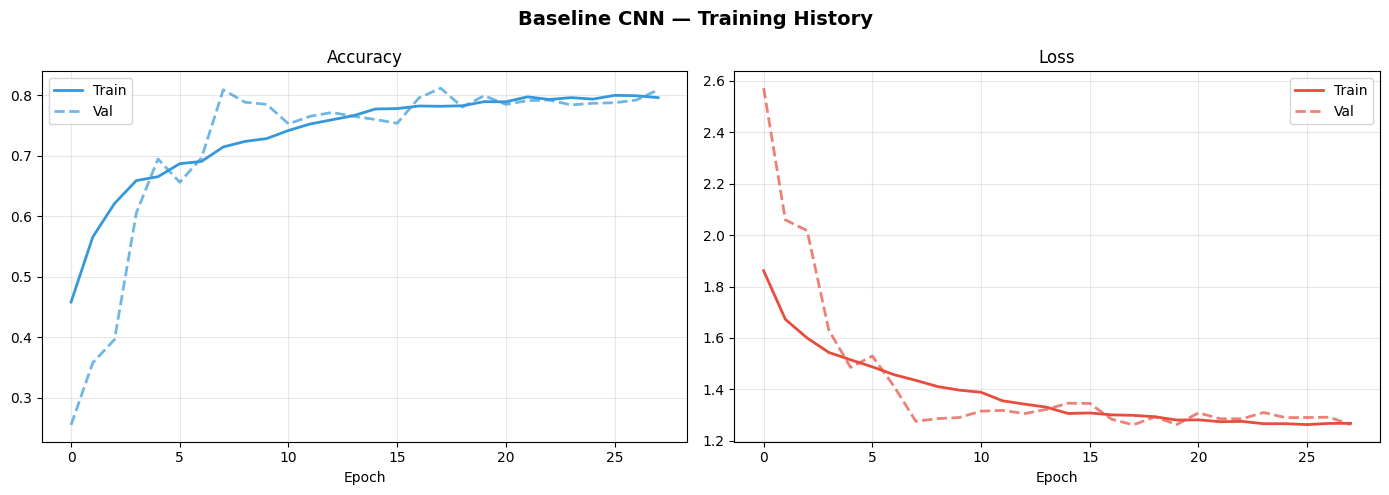

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline CNN — Training History", fontsize=14, fontweight='bold')
 
for ax, (m, title, c) in zip(axes, [('accuracy','Accuracy','#3498db'), ('loss','Loss','#e74c3c')]):
    ax.plot(history.history[m],          label='Train', color=c, linewidth=2)
    ax.plot(history.history[f'val_{m}'], label='Val',   color=c, linewidth=2, linestyle='--', alpha=0.7)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_baseline_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

This plot summarizes how my model behaved during training. On the left, accuracy increases and then stabilizes; on the right, loss decreases and then flattens. The training and validation curves are reasonably close, so I interpret this as good learning with limited overfitting.

From this figure, I can explain that the model converged and reached a stable performance region rather than diverging.

In [18]:
test_results_b = model.evaluate(test_ds, verbose=1)
 
y_pred_b = np.argmax(model.predict(test_ds, verbose=0), axis=1)
y_true_b = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])
 
print(classification_report(y_true_b, y_pred_b, target_names=CLASS_NAMES))

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.6552 - auc: 0.8558 - loss: 1.5897 - precision: 0.6994 - recall: 0.6108
              precision    recall  f1-score   support

      glioma       0.70      0.71      0.70       400
  meningioma       0.83      0.36      0.51       400
     notumor       0.77      0.93      0.84       400
   pituitary       0.71      0.95      0.81       400

    accuracy                           0.74      1600
   macro avg       0.75      0.74      0.72      1600
weighted avg       0.75      0.74      0.72      1600



In this evaluation cell, I test the trained model on unseen test data and then print a full classification report. I use this to move beyond just accuracy and discuss precision, recall, and F1-score for each class.

This output tells me how balanced the model performance is across classes and gives me a clearer view of strengths and weaknesses on real unseen samples.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 982ms/step


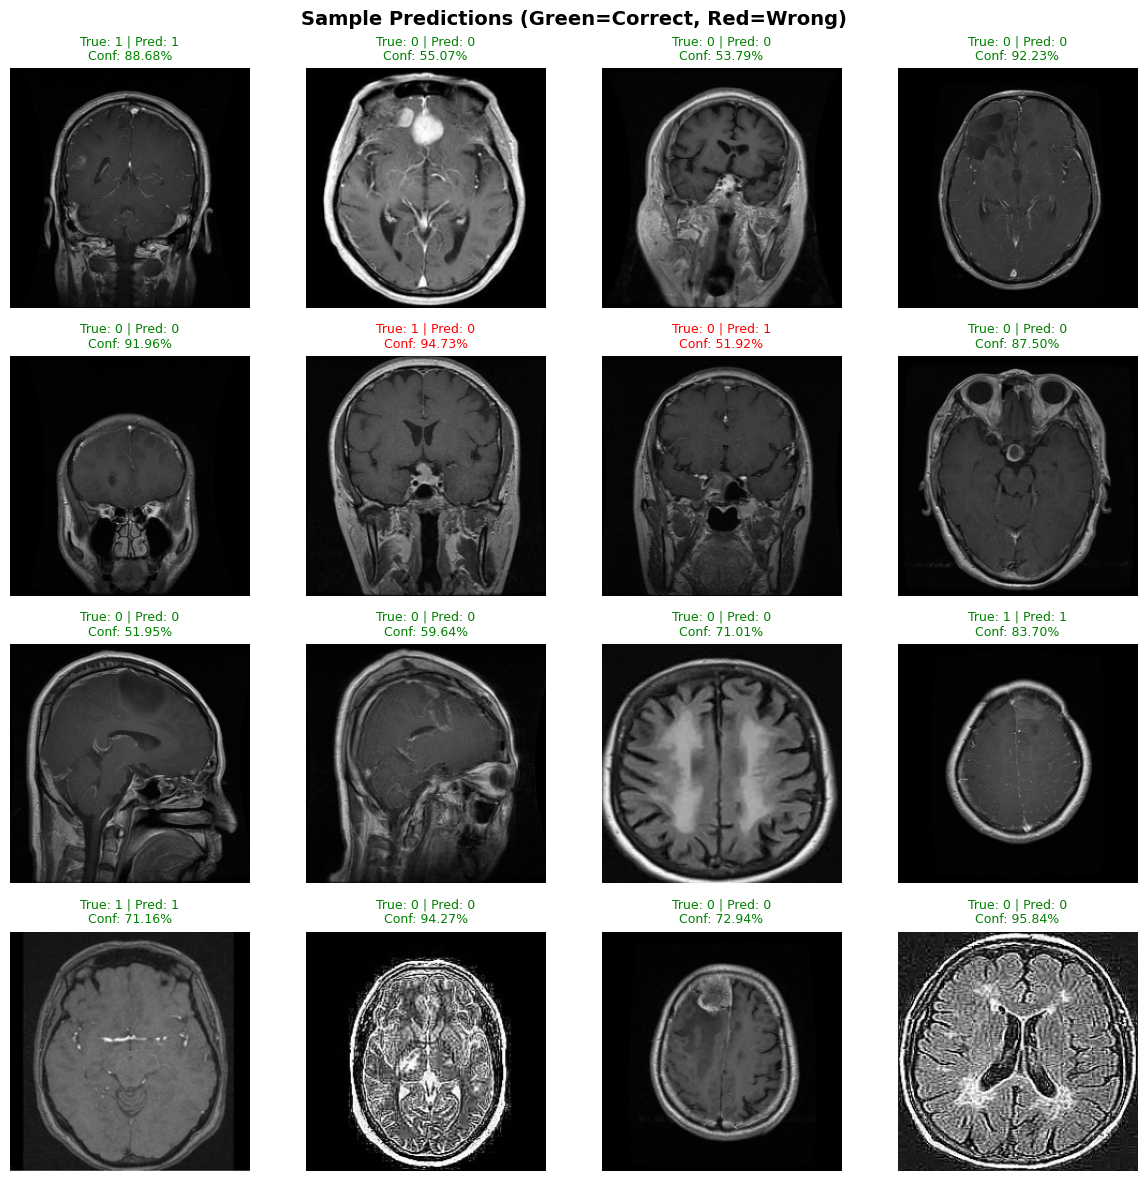

Saved to OUTPUT_DIR/sample_predictions.png


In [19]:

# Get a batch of validation images
sample_images, sample_labels = next(iter(val_ds))

# Get predictions
predictions = model.predict(sample_images)

# If binary classification
predicted_classes = (predictions > 0.5).astype(int).flatten()

# If multi-class classification
# predicted_classes = np.argmax(predictions, axis=1)
# true_classes = np.argmax(sample_labels.numpy(), axis=1)  # if one-hot encoded

true_classes = sample_labels.numpy().astype(int).flatten()

# Plot sample images with predictions
n_samples = 16  # number of images to display
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i in range(n_samples):
    img = sample_images[i].numpy()
    
    # Denormalize if needed (if images were normalized to [0,1] skip this)
    img = np.clip(img, 0, 1)
    
    axes[i].imshow(img)
    
    pred_label  = predicted_classes[i]
    true_label  = true_classes[i]
    confidence  = predictions[i][0] if predictions.shape[-1] == 1 else np.max(predictions[i])
    
    # Color code: green = correct, red = wrong
    color = 'green' if pred_label == true_label else 'red'
    
    axes[i].set_title(
        f"True: {true_label} | Pred: {pred_label}\nConf: {confidence:.2%}",
        color=color, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to OUTPUT_DIR/sample_predictions.png")

Here I do a qualitative check by visualizing 16 validation images with true label, predicted label, and confidence. Green titles show correct predictions and red titles show mistakes.

I use this to explain model behavior visually: even when overall metrics are good, the wrong red cases reveal where the model is still confused. Confidence values help me discuss whether errors happen with low confidence (uncertain) or high confidence (overconfident mistakes).